# INSTALL DEPENDENCIES

In [1]:
INITAL_SETUP = True

if INITAL_SETUP:
    %pip install fastkaggle
    %pip install kaggle
    %pip install dotenv
    %pip install ipdb
    %pip install fastai



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.2/33.2 MB 104.0 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.0/875.0 kB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import fastkaggle
import pandas as pd
import numpy as np
from pathlib import Path
import shutil
import os
from fastai.tabular import *
from fastai.tabular.all import *
from fastai.vision.all import *

PATH_LOCAL_PATH_DATA_STORAGE = Path(r'D:\kaggle_data')
COMPETITION_NAME = '104-flowers-garden-of-eden'


# CHECK IF RUNNING ON KAGGLE OR ELSEWHERE

In [3]:
'Kaggle' if fastkaggle.iskaggle else 'Not Kaggle'

'Kaggle'

# PREPARE KAGGLE DATA

In [4]:
FORMAT_SIZE = "jpeg-192x192"

if fastkaggle.iskaggle:
    #path = os.path.join(Path('../input'), COMPETITION_NAME) # generates path containing competition name
    #for dirname, _, filenames in os.walk('/kaggle/input'):
    #    for filename in filenames:
            #print(os.path.join(dirname, filename))
    #        pass
    path = os.path.join('/kaggle/input/datasets/msheriey/104-flowers-garden-of-eden',
                       FORMAT_SIZE) # generates path containing competition name
    
else:
    path = os.path.join(Path(PATH_LOCAL_PATH_DATA_STORAGE), COMPETITION_NAME) # generates path containing competition name
    path = os.path.join(path, 'versions', '1', FORMAT_SIZE) # generates path containing competition name

path
    


'/kaggle/input/datasets/msheriey/104-flowers-garden-of-eden/jpeg-192x192'

In [5]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("msheriey/104-flowers-garden-of-eden")

# print("Path to dataset files:", path)

# Check out the images

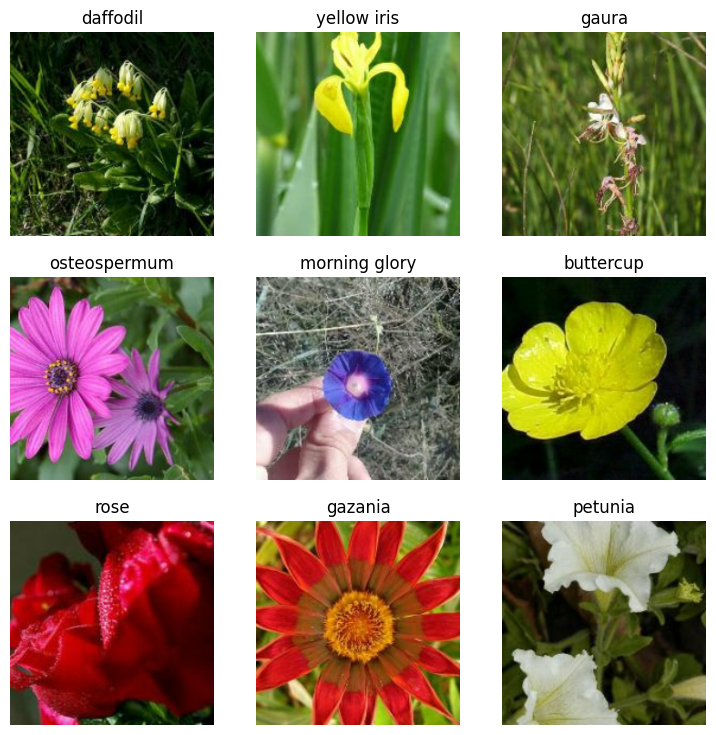

In [6]:
# dls = ImageDataLoaders.from_name_func(
#     path,                                # path to images 
#     get_image_files(path),               # get the list of path for all images
#     valid_pct = 0.25,                    # percentages to use for validation
#     seed = 42,                           # random seed
#     label_func = parent_label,          # labelling for the images
#     item_tfms = Resize(224))             # transform the images to 224x224


dls = ImageDataLoaders.from_folder(
    path,                                # path to images 
    train='train',
    valid='val',
    blocks = (ImageBlock, CategoryBlock),       # specify the type of data
    seed = 42,                           # random seed
    #label_func = parent_label,          # labelling for the images
    get_y = parent_label,
    item_tfms = Resize(192))             # transform the images to 224x224

dls.show_batch()

In [7]:
for vocab in dls.vocab:
    print(vocab)

alpine sea holly
anthurium
artichoke
azalea
balloon flower
barberton daisy
bee balm
bird of paradise
bishop of llandaff
black-eyed susan
blackberry lily
blanket flower
bolero deep blue
bougainvillea
bromelia
buttercup
californian poppy
camellia
canna lily
canterbury bells
cape flower
carnation
cautleya spicata
clematis
colt's foot
columbine
common dandelion
common tulip
corn poppy
cosmos
cyclamen 
daffodil
daisy
desert-rose
fire lily
foxglove
frangipani
fritillary
garden phlox
gaura
gazania
geranium
giant white arum lily
globe thistle
globe-flower
grape hyacinth
great masterwort
hard-leaved pocket orchid
hibiscus
hippeastrum 
iris
japanese anemone
king protea
lenten rose
lilac hibiscus
lotus
love in the mist
magnolia
mallow
marigold
mexican petunia
monkshood
moon orchid
morning glory
orange dahlia
osteospermum
passion flower
peruvian lily
petunia
pincushion flower
pink primrose
pink quill
pink-yellow dahlia
poinsettia
primula
prince of wales feathers
purple coneflower
red ginger
rose
r

# Prepare dataset

TBD if any work needs to be done here. Currently just a placeholder


# Vision Learner

In [8]:
learn = vision_learner(dls, 
                       resnet18,
                       model_dir='/kaggle/working/models',
                       metrics=[accuracy, error_rate])

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 194MB/s] 


In [9]:
# import torchvision
# torchvision.__version__
# torch.__version__
# import pytorch
# pytorch.__version__

In [10]:
# import torch
# print(torch.cuda.is_available())
# print(torch.cuda.get_device_name(0))

# Fine Tune
We fine tune this model because we want to take advantage of the pretrained model. This will sever the head and retrain the last layer for our specific application. 

In [15]:
#lrs = learn.lr_find(suggest_funcs=(minimum, steep, valley, slide))

<div><div><progress max="1" value="0"></progress> 0.00% [0/1 00:00&lt;?]</div><div></div><div><progress max="199" value="0"></progress> 0.00% [0/199 00:00&lt;?]</div></div>

KeyboardInterrupt: 

In [18]:
learn.fine_tune(1, base_lr = 0.0006918309954926372 )

epoch,train_loss,valid_loss,accuracy,error_rate,time
0,1.281197,0.956905,0.751078,0.248922,17:19


epoch,train_loss,valid_loss,accuracy,error_rate,time
0,0.963207,0.805136,0.794450,0.205550,27:48


# Quick check of the results

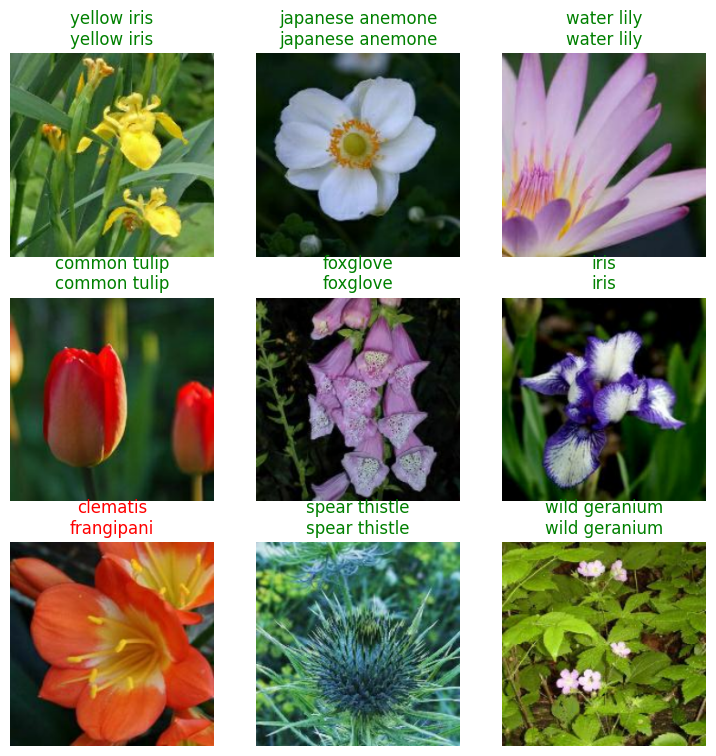

In [19]:
learn.show_results()

# Prepare testing data

Load testing data....

In [20]:
test_files = get_image_files(os.path.join(path,'test'))
print("Found {} test files.".format(len(test_files)))

Found 7382 test files.


In [21]:
dls_test = learn.dls.test_dl(test_files)

# Inference

In [22]:
preds, _, decoded = learn.get_preds(dl=dls_test, with_decoded=True)

Let's check the results

In [23]:
preds, decoded
predicted_classes = [learn.dls.vocab[i] for i in preds.argmax(dim=1)]
len(predicted_classes)
print('Length of preds:', len(preds))
print('Length of decoded:', len(decoded))
print('Length of predicted_classes:', len(predicted_classes))


Length of preds: 7382
Length of decoded: 7382
Length of predicted_classes: 7382


In [24]:
predicted_classes[:10]


['wild geranium',
 'iris',
 'rose',
 'thorn apple',
 'cosmos',
 'wild rose',
 'artichoke',
 'wild geranium',
 'wild rose',
 'iris']

In [ ]:
#learn.show_results(dl=dls_test, max_n=5)
#interp = Interpretation.from_learner(learn, dl=dls_test)
#interp.plot_top_losses(9)
#learn.dls.show_results(dls_test.one_batch(), preds, max_n=9)

In [25]:
predicted_classes[0]

'wild geranium'

In [30]:
if fastkaggle.iskaggle:
    path_submission = '/kaggle/input/competitions/tpu-getting-started/sample_submission.csv'
else:
    path_submission = os.path.join(path, '..', 'sample_submission.csv')

submission_csv = pd.read_csv(path_submission, header=0)
submission_csv.head(10)


,id,label
0,b48c962e0,0
1,a13d3dfa4,0
2,94269c190,0
3,bcb18c6e4,0
4,d15a4d94c,0
5,914b0e71b,0
6,065c9b5be,0
7,dd8b1aaca,0
8,8c39d1b41,0
9,e2fdce920,0


# Adding predictions to the submission CSV 

In [32]:
dls_test.items[:10]

[Path('/kaggle/input/datasets/msheriey/104-flowers-garden-of-eden/jpeg-192x192/test/1461713ad.jpeg'),
 Path('/kaggle/input/datasets/msheriey/104-flowers-garden-of-eden/jpeg-192x192/test/3a1d5b5db.jpeg'),
 Path('/kaggle/input/datasets/msheriey/104-flowers-garden-of-eden/jpeg-192x192/test/24aae97eb.jpeg'),
 Path('/kaggle/input/datasets/msheriey/104-flowers-garden-of-eden/jpeg-192x192/test/5e2692d15.jpeg'),
 Path('/kaggle/input/datasets/msheriey/104-flowers-garden-of-eden/jpeg-192x192/test/ce6f860f1.jpeg'),
 Path('/kaggle/input/datasets/msheriey/104-flowers-garden-of-eden/jpeg-192x192/test/f67596886.jpeg'),
 Path('/kaggle/input/datasets/msheriey/104-flowers-garden-of-eden/jpeg-192x192/test/aab3a2289.jpeg'),
 Path('/kaggle/input/datasets/msheriey/104-flowers-garden-of-eden/jpeg-192x192/test/4fdd76274.jpeg'),
 Path('/kaggle/input/datasets/msheriey/104-flowers-garden-of-eden/jpeg-192x192/test/3aa882bbe.jpeg'),
 Path('/kaggle/input/datasets/msheriey/104-flowers-garden-of-eden/jpeg-192x192/tes

In [33]:
# Get the original filenames/paths
file_names = [f.name.replace('.jpeg', '') for f in dls_test.items]
file_names[:10]

['1461713ad',
 '3a1d5b5db',
 '24aae97eb',
 '5e2692d15',
 'ce6f860f1',
 'f67596886',
 'aab3a2289',
 '4fdd76274',
 '3aa882bbe',
 'df5a78c3d']

In [34]:
# Combine them into a dictionary or list for easy viewing
results = list(zip(file_names, predicted_classes))
results[:10]
d_results = dict(results)

In [35]:
print(submission_csv.loc[0, 'id'] )
print(submission_csv.loc[0, 'label'] )

b48c962e0
0


In [36]:
submission_csv['label'] = submission_csv['label'].astype(str)

for index, row in submission_csv.iterrows():
    #print('index', index)
    #print('row id', row['id'])
    #print('row label', row['label'])
    matched_index = d_results.get(row['id'])
    #print('new label', matched_index)
    submission_csv.loc[index, 'label'] = matched_index
    #print('row label after', row['label'])
    # if index>10:
    #     break'

In [37]:
submission_csv.head(10)

,id,label
0,b48c962e0,corn poppy
1,a13d3dfa4,petunia
2,94269c190,rose
3,bcb18c6e4,wild geranium
4,d15a4d94c,common dandelion
5,914b0e71b,sweet william
6,065c9b5be,pink-yellow dahlia
7,dd8b1aaca,watercress
8,8c39d1b41,cosmos
9,e2fdce920,wild geranium


In [39]:
submission_csv.to_csv('submission.csv', index=False)